In [1]:
################################## attention layer ##################################
import numpy as np
import scipy.io
from sklearn import metrics
import pandas as pd
import os
import scipy.io as sio
import os.path
import time
import random
import math

import tensorflow.keras as keras
import tensorflow as tf
import matplotlib.pyplot as plt

from keras.layers import Embedding
from keras.models import Model
from keras.layers import Dense, Dropout, Activation, Flatten, Layer, merge, Input, Concatenate, Reshape
from keras.layers.convolutional import Conv1D, MaxPooling1D
from keras.layers.pooling import GlobalMaxPooling1D
from keras.layers.recurrent import LSTM
from keras.layers.wrappers import Bidirectional, TimeDistributed
from keras.models import load_model
from keras.callbacks import ModelCheckpoint, EarlyStopping
from keras import backend as K
import tensorflow.keras as keras
import tensorflow as tf
import matplotlib.pyplot as plt

In [2]:
gpu_devices = tf.config.experimental.list_physical_devices('GPU')
for device in gpu_devices:
    tf.config.experimental.set_memory_growth(device, True)

In [2]:
# Library of Helper Functions

def readInputAsArray(fileName):
    with open(fileName, 'r') as myfile:
        data = myfile.readlines()

    # Strip newline
    for i in range(0, len(data)):
        data[i] = data[i].rstrip()
    # print(data)
    return data

def readInputAsString(fileName):
    with open(fileName, 'r') as myfile:
        data=myfile.read().replace('\n', ' ')
        # print 
    return data

def reverse_complement(seq):    
    complement = {'A': 'T', 'C': 'G', 'G': 'C', 'T': 'A'}
    reverse_complement = ''.join(complement.get(base, base) for base in reversed(seq))
    return reverse_complement

def oneHotEncode(seq):
    import numpy as np
    seq2=list()
    mapping = {"A":[1., 0., 0., 0.], "C": [0., 1., 0., 0.], "G": [0., 0., 1., 0.], "T":[0., 0., 0., 1.]};
    for i in seq:
    	seq2.append(mapping[i]  if i in mapping.keys() else [0., 0., 0., 0.]);
    return seq2;

def ReverseOneHotEncode(arr):
    seq = ''
    nuc_map = ['A', 'C', 'G', 'T']
    for subarr in arr:
        nuc = nuc_map[np.argmax(subarr)]
        seq+=nuc
    return seq;

def writeSeqToFile(d,ones,zeros):
    fname = '/Users/yibeijia/Downloads/nucleosome_occupancy/data/SeqsForFeature.txt'
#     fname='/home/yibei/Projects/nucleosome_occupancy/data/SeqsForFeature.txt'
    out = 'Enriched:\n'
    for i in ones:
        seq = ReverseOneHotEncode(d[i])
        out = out + str(1) + ' ' + seq + '\n'
    out += 'Depleted:\n'
    for i in zeros:
        seq = ReverseOneHotEncode(d[i])
        out = out + str(0) + ' ' + seq + '\n'
    with open(fname, 'w+') as f:
        f.write(out)      
        
def tokenize(str):
    out = []
    for i in range(len(str)-4):
        out.append(str[i:i+5])
    return out

# Normalize an array 
def min_max_norm(arr):
    new_arr = []
    min_v = min(arr)
    max_v = max(arr)
    for num in arr:
        new_arr=new_arr+[(num-min_v)/(max_v-min_v)]
    return(new_arr)

def read_SD_table(fileName):
    tb_data = readInputAsArray(fileName)
    tb = {}
    DNAshape = tb_data[0].split("\t")
    # print(DNAshape)
    for i in range(1, len(tb_data)):
        line = tb_data[i].split("\t")
        key = line[0]
        value = line[1:]
        for j in range(0, len(value)):
            value[j] = float(value[j])
        tb[key] = value
    # print(tb)
    return(tb)

In [3]:
# Helper function to plot data colored with attention weights
class CharVal(object):
    def __init__(self, char, val):
        self.char = char
        self.val = val

    def __str__(self):
        return self.char

def rgb_to_hex(rgb):
    return '#%02x%02x%02x' % rgb

def color_charvals(s):
    r = 255-int(s.val*255)
#     r = int(s.val*255)
#     print(r)
    color = rgb_to_hex((r, r, 255))
    return 'background-color: %s' % color

# a list of 5mers, token and a list of their attention values, currseq_attention_output
def plot_attention_from_seq(token, currseq_attention_output):

    vals_normalized = min_max_norm(currseq_attention_output)
#     print(vals_normalized)
    # match each 5mer with sum of the 320 dim array attention weight array
    char_vals = [CharVal(c, v) for c, v in zip(token, vals_normalized)]
    char_df = pd.DataFrame(char_vals).transpose()
    # apply coloring values
    char_df = char_df.style.applymap(color_charvals)
    return char_df


def plot_attention_from_map(map):

    # match each 5mer with sum of the 320 dim array attention weight array
    vals_normalized = min_max_norm(map.values())
    char_vals = [CharVal(c, v) for c, v in zip(map.keys(), vals_normalized)]
    char_df = pd.DataFrame(char_vals).transpose()
    # apply coloring values
    char_df = char_df.style.applymap(color_charvals)
    return char_df

In [4]:
data_folder = "/Users/yibeijia/Downloads/nucleosome_occupancy/tbinet_stuff/model2/"

data_folder = "/Users/yibeijia/Downloads/nucleosome_occupancy/tbinet_stuff/model2_reduced_dense10/"
data_folder = "/Users/yibeijia/Downloads/nucleosome_occupancy/tbinet_stuff/model3/"
data_folder = "/Users/yibeijia/Downloads/nucleosome_occupancy/tbinet_stuff/train_dense10_kernel9_run3/"
# data_folder = "/home/yibei/Projects/nucleosome_occupancy/tbinet_stuff/train_dense10_kernel10_run3/"
model = load_model(data_folder+"tbinet.h5")

model.summary()



Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 147, 4)]     0                                            
__________________________________________________________________________________________________
conv1d (Conv1D)                 (None, 147, 320)     13120       input_1[0][0]                    
__________________________________________________________________________________________________
max_pooling1d (MaxPooling1D)    (None, 143, 320)     0           conv1d[0][0]                     
__________________________________________________________________________________________________
dropout (Dropout)               (None, 143, 320)     0           max_pooling1d[0][0]              
______________________________________________________________________________________________

# 1. Generate Attention weights for all data

In [5]:
def generateAttentionWeights(model):
    ## load model with its attention weights using the layer
#     attention_wt_model = tf.keras.models.Model(inputs=model.inputs, outputs=[model.output, model.get_layer('multiply').output])
    attention_wt_model = tf.keras.models.Model(inputs=model.inputs, outputs=[model.output, model.get_layer('attention2').output])
    ## Set up a set of data for predict call, this case, taking every 10 data point
#     data_folder = "/home/yibei/Projects/nucleosome_occupancy/data/train_test_data/"
    data_folder = "/Users/yibeijia/Downloads/nucleosome_occupancy/data/train_test_data/"

    # load testmat from file
    testmat = scipy.io.loadmat(data_folder+'worm_Test_data.mat')
    batches = 10
    batch_size = round(len(testmat['Test_data'])/batches)
    print(f"batch_size: {batch_size}; batches: {batches}")
    model_outputs=[]
    attention_outputs=[]
    model_outputs0=[]
    attention_outputs0=[]
    model_outputs1=[]
    attention_outputs1=[]

    for i in range(batches):
#     for i in range(2):
        start = i*batch_size
        end = (i+1)*batch_size
        print(f"start: {start}; end: {end}")
        d = testmat['Test_data'][start:end]
        labels = testmat['Test_labels']
        new_labels = labels[0][start:end]

        # get the index of data that is 0 or 1 
        ones = np.flatnonzero(new_labels == np.max(new_labels))
        zeros = np.flatnonzero(new_labels == np.min(new_labels))
    #     print(f'ones.shape {ones.shape}')
    #     print(f'zeros.shape {zeros.shape}')

        # # get all model output and attention weights
        attention_wt = attention_wt_model.predict(np.transpose(d,axes=(0,1,2)))
        model_out = attention_wt[0]
        attention_out = attention_wt[1]
    #     print(f'model.shape {len(model_out)}')

        # separate 0 and 1
        attention_out0 = [attention_out[i] for i in zeros]
        attention_out1 = [attention_out[i] for i in ones]
#         model_out0 = [model_out[i] for i in zeros]
#         model_out1 = [model_out[i] for i in ones]

        # Concatenate current batch with the rest of batches
        if len(attention_outputs) == 0: # if initialize
#             model_outputs = model_out
#             model_outputs0 = model_out0
#             model_outputs1 = model_out1

            attention_outputs = attention_out
            attention_outputs0 = attention_out0
            attention_outputs1 = attention_out1
#             print(attention_outputs)

        else:
#             model_outputs = np.concatenate((model_outputs, model_out), axis=0)
#             model_outputs1 = np.concatenate((model_outputs1, model_out1), axis=0)
#             model_outputs0 = np.concatenate((model_outputs0, model_out0), axis=0)
            attention_outputs = np.concatenate((attention_outputs, attention_out), axis=0)
            attention_outputs0 = np.concatenate((attention_outputs0, attention_out0), axis=0)
            attention_outputs1 = np.concatenate((attention_outputs1, attention_out1), axis=0)

#     r = len(attention_outputs)
#     c = len(attention_outputs[0])
#     l = len(attention_outputs[0][0])
#     print(f"The all attention_outputs Array is {r} x {c} x {l}")

#     r = len(attention_outputs0)
#     c = len(attention_outputs0[0])
#     l = len(attention_outputs0[0][0])
#     print(f"The 0 attention_outputs Array is {r} x {c} x {l}")

#     r = len(attention_outputs1)
#     c = len(attention_outputs1[0])
#     l = len(attention_outputs1[0][0])
#     print(f"The 1 attention_outputs Array is {r} x {c} x {l}")
    return attention_outputs, attention_outputs0, attention_outputs1

In [6]:
attention_outputs, attention_outputs0, attention_outputs1 = generateAttentionWeights(model)

batch_size: 53214; batches: 10
start: 0; end: 53214
start: 53214; end: 106428
start: 106428; end: 159642
start: 159642; end: 212856
start: 212856; end: 266070
start: 266070; end: 319284
start: 319284; end: 372498
start: 372498; end: 425712
start: 425712; end: 478926
start: 478926; end: 532140


In [7]:
np.save(f"/Users/yibeijia/Downloads/data/attention_outputs_analyze_attention_worm.npy", attention_outputs)

In [11]:
print(len(attention_outputs))

532140


# 1. Plot attention score from run10 model for all 5mers

In [9]:
# # if you are using batches the outputs will be in batches
# # get exact attentions of chars
# i=0 #get attention map for ith sequence
# currseq_attention_output = sum(attention_outputs[i])
# token = tokenize(ReverseOneHotEncode(d[i]))
# char_df = plot_attention_from_seq(token, currseq_attention_output)
# (char_df)

In [10]:
# mapped = dict(zip(token, currseq_attention_output))
# print(mapped)

## 1.1 Don't add reverse Complements scores and treat them separately

In [12]:
# Put all the 5mers and their added total attention scores across sequences in dictionary
def sumAttentionforAllKmers(attention_outputs, d):
    from IPython.display import display
    mapped = {}
    kmerCounts = {}
    seqCount=0

    print(f"Total Attention Seq Num: {len(attention_outputs)}")
    print(f"Total Data Seq: {len(d)}")
    
    for seq in range(len(attention_outputs)):
        seqCount+=1
    # for seq in range(1,500):

        # tokens are the 5mers in the current sequence
        tokens = tokenize(ReverseOneHotEncode(d[seq]))

        # for 147bp each sequence, there are 320 feature scores for each bp
        #     for i in range(len(attention_outputs[0])):
        for i in range(len(tokens)):
    #         print(token)
            token = tokens[i]
            if token in kmerCounts.keys():
                kmerCounts[token] = kmerCounts[token] + 1
            else:
                kmerCounts[token] = 1
#             five_mer_attention_output = sum(attention_outputs[seq][i])
            five_mer_attention_output = attention_outputs[seq][i]
            if token in mapped.keys():  # if a 5mer is found
                mapped[token] = mapped[token] + five_mer_attention_output #increase value
            else: #if 5mer not seen yet
                mapped[token] = five_mer_attention_output
        
    #     char_df = plot_attention_from_seq(tokens, mapped[token])
    #     display(char_df)

    # Plot the mapped dictionary for each 5 mer; Darker means higher attention score
    import collections
    ordered_map = collections.OrderedDict(sorted(mapped.items()))
    return ordered_map, kmerCounts, seqCount


In [14]:
data_folder = "/Users/yibeijia/Downloads/nucleosome_occupancy/data/train_test_data/"
# data_folder = "/home/yibei/Projects/nucleosome_occupancy/data/train_test_data/"

# load testmat from file
testmat = scipy.io.loadmat(data_folder+'worm_Test_data.mat')
d=testmat['Test_data'] # need to redefine d
labels = testmat['Test_labels']
new_labels = labels[0]

# get the index of data that is 0 or 1 
# ones = np.flatnonzero(new_labels == np.max(new_labels))
# zeros = np.flatnonzero(new_labels == np.min(new_labels))
# d0 = [d[i] for i in zeros]
# d1 = [d[i] for i in ones]

# print("Depleted Seqs")
# ordered_map0, kmerCounts0, seqCount0 = sumAttentionforAllKmers(attention_outputs0, d0)
# print("Enriched Seqs")
# ordered_map1, kmerCounts1, seqCount1 = sumAttentionforAllKmers(attention_outputs1, d1)
print("ALL Seqs")
ordered_map, kmerCounts, seqCount = sumAttentionforAllKmers(attention_outputs, d)
# print(f"seqCount0: {seqCount0}")
# print(f"seqCount1: {seqCount1}")
print(f"seqCount: {seqCount}")

ALL Seqs
Total Attention Seq Num: 532140
Total Data Seq: 532142
seqCount: 532140


In [15]:
def normSeqCount(ordered_map, seqCount):
    ordered_map_norm = {}
    for k, _ in ordered_map.items():
        v = ordered_map[k] / seqCount
        ordered_map_norm[k] = v
    return ordered_map_norm

In [16]:
ordered_map_norm = normSeqCount(ordered_map, seqCount)
# ordered_map_norm0 = normSeqCount(ordered_map0, seqCount0)
# ordered_map_norm1 = normSeqCount(ordered_map1, seqCount1)

print(len(ordered_map_norm))
# print(len(ordered_map))
# print(len(ordered_map_norm0))
# print(len(ordered_map_norm1))

1024


In [17]:
max(ordered_map_norm.values())

0.020395548369555004

In [18]:
AllDNAshape = ['Shear', 'Stretch', 'Stagger', 'Buckle', 'Propel', 'Opening', 
'Shift_-1', 'Shift_1', 'Slide_-1', 'Slide_1', 'Rise_-1', 'Rise_1',
            'Tilt_-1', 'Tilt_1', 
'Roll_-1', 'Roll_1', 'Twist_-1', 'Twist_1', 'mingw', 'mingd', 'majgw', 'majgd', 
'Shear-SD', 'Stretch-SD', 'Stagger-SD', 'Buckle-SD', 'Propel-SD', 'Opening-SD', 
'Shift-SD', 'Slide-SD', 'Rise-SD', 'Tilt-SD', 'Roll-SD', 'Twist-SD', 'mingw-SD', 
'mingd-SD', 'majgw-SD', 'majgd-SD']

All_params_names = ["intra_trans","intra_rot","inter_trans","inter_rot","GrooveWidth","intra_trans_SD","inter_trans_SD","intra_rot_SD","inter_rot_SD","GrooveWidth_SD"]

# fileName = "/Users/yibeijia/Downloads/ProjectStuff/mc_pentamer_06042020.txt"
fileName = "/Users/yibeijia/Downloads/ProjectStuff/pentamer_table.txt"
# fileName = "/home/yibei/Projects/nucleosome_occupancy/mc_pentamer_06042020.txt"
tb = read_SD_table(fileName);

# all_norm_shape_vals, all_shape_vals2 = shape_param_analysis(tb)
# print(len(all_norm_shape_vals))
len(tb.keys())

1024

In [19]:
################################### Correlation plots for reverse complements ###################################
def reverseCompPlot(map_to_plot, plot_name, annotation_x, annotation_y, removeA):
    import seaborn as sns
    import matplotlib.pyplot

    i=0
    five_mers = {}
    for k in map_to_plot.items():
        if k[0] in tb.keys(): #k[0] is not a reverse complement

            r = reverse_complement(k[0])
            values = [map_to_plot[k[0]], map_to_plot[r]] #first is 5mer, second is reverse complement value
            five_mers[k[0]] = values

    # Plot corr between 5mers and its reverse complements
    corr = pd.DataFrame.from_dict(five_mers,orient='index', columns=['five_mer', 'reverse_comp'])
    if removeA:
        corr = corr[1:]
        plot_name+='_removeA'
    
    sns.set_theme(style="darkgrid")

    g = sns.lmplot(x="five_mer", y="reverse_comp",data=corr);

    plt.gcf().set_size_inches(10, 8)
    # plt.title("Attension Score Correlation: \n5-mers vs. Reverse Complements\nafter Normalization", fontsize=15)
    plt.xlabel("5-mers Attention Scores", fontsize=25);
    
    plt.ticklabel_format(style='sci',scilimits=(0,0))
    plt.xticks(fontsize=20);
    plt.yticks(fontsize=20);
    plt.ylabel("Reverse complements Attention Scores", fontsize=25);

    # Add person correlation annotation
    from scipy import stats
    num = stats.pearsonr(corr['five_mer'], corr['reverse_comp'])[0]
    text = "Pearson Correlation \n= " + f'{num:.5f}'

    plt.text(annotation_x, annotation_y, text, horizontalalignment='center', fontsize=20, color='black', weight='semibold')
    
    plt.tight_layout()
    plt.savefig( plot_name+'.png', dpi=200)

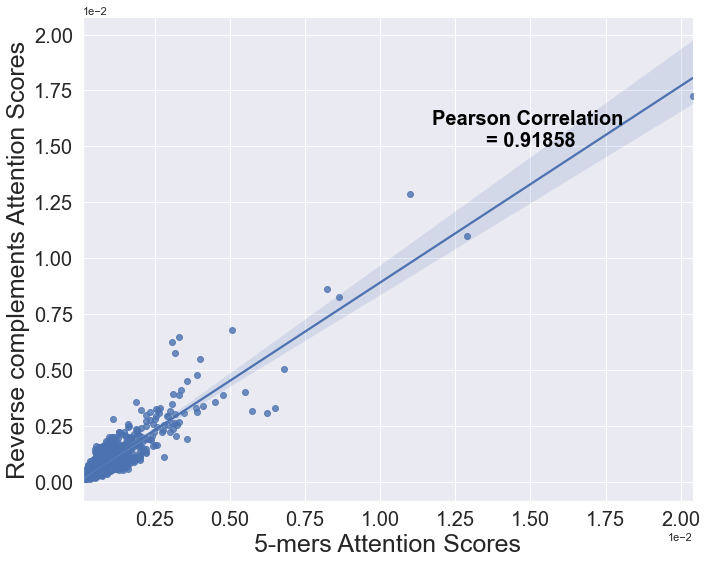

In [20]:
# fig_path='/home/yibei/Projects/nucleosome_occupancy/figs/'
fig_path='/Users/yibeijia/Downloads/nucleosome_occupancy/figs/'

# reverseCompPlot(ordered_map, fig_path + 'ordered_map_all.png', 0, 0)
reverseCompPlot(ordered_map_norm, fig_path + 'ordered_map_all_norm_worm', 0.015, 0.015, True)
# reverseCompPlot(ordered_map_norm, fig_path + 'ordered_map_all', 0.015, 0.015, False)


## 1.2 Add reverse complement scores to 5mer scores

In [21]:
def addReversCompScores(attention_outputs, d):
    # if you are using batches the outputs will be in batches
    # get exact attentions of chars
    from IPython.display import display
    mapped_add = {}
    seqCounts = 0
#     testmat = scipy.io.loadmat(data_folder+'Test_data.mat')
#     d = testmat['Test_data']
    for seq in range(len(attention_outputs)):
        seqCounts+=1
    # for seq in range(1,5):

        # tokens are the 5mers in the current sequence
        tokens = tokenize(ReverseOneHotEncode(d[seq]))

        # for 147bp each sequence, there are 320 feature scores for each bp
        for i in range(len(tokens)):
            token = tokens[i]
#             five_mer_attention_output = sum(attention_outputs[seq][i])
            five_mer_attention_output = attention_outputs[seq][i]
            if token in mapped_add.keys():  # if a 5mer is found
                mapped_add[token] = mapped_add[token] + five_mer_attention_output #increase value
                mapped_add[reverse_complement(token)] = mapped_add[token] #set the reverse compliement value to the same

            # if a 5mer's reverse complement is found
            elif reverse_complement(token) in mapped_add.keys():
                mapped_add[reverse_complement(token)] = mapped_add[reverse_complement(token)] + five_mer_attention_output
                mapped_add[token] = mapped_add[reverse_complement(token)] #set the original 5mer value to the same

            #if 5mer not seen yet
            else: 
                mapped_add[token] = five_mer_attention_output
                mapped_add[reverse_complement(token)] = mapped_add[token]
    #     char_df = plot_attention_from_seq(tokens, mapped[token])
    #     display(char_df)

    # Plot the mapped dictionary for each 5 mer; Darker means higher attention score
    import collections
    ordered_map_add = collections.OrderedDict(sorted(mapped_add.items()))
    # char_df = plot_attention_from_map(mapped_add)
    # display(char_df)
    # char_df = plot_attention_from_map(ordered_map_add)
    # display(char_df)
    return ordered_map_add, seqCounts

In [22]:
data_folder = "/Users/yibeijia/Downloads/nucleosome_occupancy/data/train_test_data/"
# data_folder = "/home/yibei/Projects/nucleosome_occupancy/data/train_test_data/"

# load testmat from file
testmat = scipy.io.loadmat(data_folder+'worm_Test_data.mat')
    
d=testmat['Test_data'] # need to redefine d
labels = testmat['Test_labels']
new_labels = labels[0]

ordered_map_add, seqCounts = addReversCompScores(attention_outputs, d)
print("done")

done


In [23]:
# print(ordered_kmerCounts.keys())
def normSeqCount_addReverse(ordered_map, seqCounts):
    ordered_map_add_norm = {}
    for k, _ in ordered_map.items():
        r = reverse_complement(k)
        v = ordered_map[k]/ seqCounts
        ordered_map_add_norm[k] = v
    return ordered_map_add_norm

In [24]:
print(len(ordered_map_add.keys()))
print(ordered_map_add['AAAAA'])
print(ordered_map_add['TTTTT'])
ordered_map_add_norm = normSeqCount_addReverse(ordered_map_add, seqCounts)

1024
20037.092
20037.092


In [25]:
ordered_map['CGCGC']

112.35245

In [26]:
ordered_map['ATATA']

917.1356

In [27]:
ordered_map['AAAAA']

9183.475

# 3. Shape vs Attention Score Corr Bar plots

In [28]:
#################### Add person correlation annotation All Normalized ###################
def plotAttention(whichAttention, shape_order, title):
    from scipy import stats
    AllDNAshape = ['Shear', 'Stretch', 'Stagger', 
'Buckle', 'ProT', 'Opening', 'MGW', 'EP', 'Shear-FL', 'Stretch-FL', 'Stagger-FL', 'Buckle-FL',
'ProT-FL', 'Opening-FL', 'MGW-FL', 'Shift_-1', 'Shift_1', 'Slide_-1', 'Slide_1', 'Rise_-1',
'Rise_1', 'Tilt_-1', 'Tilt_1', 'Roll_-1', 'Roll_1', 'HelT_-1', 'HelT_1', 'Shift-FL_-1', 
'Shift-FL_1', 'Slide-FL_-1', 'Slide-FL_1', 'Rise-FL_-1', 'Rise-FL_1', 'Tilt-FL_-1', 'Tilt-FL_1', 
'Roll-FL_-1', 'Roll-FL_1', 'HelT-FL_-1', 'HelT-FL_1']
    
    all_shape_df = {}
    for shape in AllDNAshape:
        cor = stats.pearsonr(shape_df[shape], shape_df[whichAttention])[0]
        pval = stats.pearsonr(shape_df[shape], shape_df[whichAttention])[0]
        r2 = stats.pearsonr(shape_df[shape], shape_df[whichAttention])[0]**2
        all_shape_df[shape] = [cor]

    #     print(f"{shape} vs. attention_score | Pearson: {cor:.5f}, P-value {pval:.5f} | R^2: {r2:.5f}")

    df = pd.DataFrame.from_dict(all_shape_df, orient='index', columns=['Pearson'])
    df["Shapes"] =all_shape_df.keys()
    
#     if (whichAttention == 'attention_score' or whichAttention == 'attention_score_norm'):
    if (whichAttention == 'attention_score'):
        df_sorted = df.sort_values(by=['Pearson'])
        shape_order = df_sorted['Shapes']
    else:
        for s in range(len(shape_order)):
            df.loc[shape_order[s], 'order'] = s
        df_sorted = df.sort_values(by=['order'])
#     p= sns.color_palette("Greens_d", len(df_sorted))
    p= sns.color_palette("mako", len(df_sorted))
    rank = df_sorted["Pearson"].argsort().argsort()
    
    #rocket
    ax = sns.catplot(y="Shapes",x="Pearson",data=df_sorted, kind="bar", edgecolor=".6", height=10,palette=np.array(p[::-1])[rank])

    ax.set_axis_labels("Pearson Correlation", "Shapes", fontsize=18)
    ax.set_yticklabels(fontsize=12)
    ax.set_xticklabels(fontsize=12)
    ax.set_titles(title,fontsize=12)

    plt.tight_layout()
    plt.title(whichAttention)
    if whichAttention == 'attention_score': whichAttention=whichAttention+"_all"
    if whichAttention == 'attention_score_norm': whichAttention=whichAttention+"norm_all"
    plt.savefig( fig_path + whichAttention + '.png', dpi=200, bbox_inches='tight')
    return shape_order, df_sorted


In [29]:
tb['AAAAA']

[0.1585,
 -0.0098,
 -0.0836,
 8.002,
 -14.9156,
 -2.0769,
 3.8846,
 -10.6188,
 0.2544,
 0.1209,
 0.3444,
 8.1741,
 7.1416,
 4.7619,
 1.3501,
 -0.0859,
 -0.0859,
 -1.0338,
 -1.0338,
 3.2774,
 3.2774,
 -0.9298,
 -0.9298,
 -4.685,
 -4.685,
 37.6927,
 37.6927,
 0.5549,
 0.5549,
 0.446,
 0.446,
 0.2934,
 0.2934,
 3.3414,
 3.3414,
 5.8623,
 5.8623,
 3.9465,
 3.9465]

In [44]:
shapes = ['Shear', 'Stretch', 'Stagger', 
'Buckle', 'ProT', 'Opening', 'MGW', 'EP', 'Shear-FL', 'Stretch-FL', 'Stagger-FL', 'Buckle-FL',
'ProT-FL', 'Opening-FL', 'MGW-FL', 'Shift_-1', 'Shift_1', 'Slide_-1', 'Slide_1', 'Rise_-1',
'Rise_1', 'Tilt_-1', 'Tilt_1', 'Roll_-1', 'Roll_1', 'HelT_-1', 'HelT_1', 'Shift-FL_-1', 
'Shift-FL_1', 'Slide-FL_-1', 'Slide-FL_1', 'Rise-FL_-1', 'Rise-FL_1', 'Tilt-FL_-1', 'Tilt-FL_1', 
'Roll-FL_-1', 'Roll-FL_1', 'HelT-FL_-1', 'HelT-FL_1']

for i in range(len(tb['TTTTT'])):
    if  tb['TTTTT'][i] != tb['AAAAA'][i]:
        print(shapes[i])

Shear
Buckle
Shift_-1
Shift_1
Tilt_-1
Tilt_1


In [30]:
################################### Correlation plots for DNA shape ###################################
import seaborn as sns
import matplotlib.pyplot

# use added reverse complement score way
attention_score0 = []
attention_score1 = []
attention_score = []
attention_score_norm0 = []
attention_score_norm1 = []
attention_score_norm = []

for k in tb.items(): # set values to the 5mer order as seen in tb
    attention_score.append(ordered_map_add[k[0]]) 
    attention_score0.append(ordered_map_add0[k[0]])
    attention_score1.append(ordered_map_add1[k[0]])
    
    attention_score_norm.append(ordered_map_add_norm[k[0]]) 
    attention_score_norm0.append(ordered_map_add_norm0[k[0]])
    attention_score_norm1.append(ordered_map_add_norm1[k[0]])

# shape_df =  pd.DataFrame.from_dict(tb,orient='index', columns=['Shear', 'Stretch', 'Stagger', 'Buckle', 'Propel', 'Opening', 
# 'Shift_-1', 'Shift_1', 'Slide_-1', 'Slide_1', 'Rise_-1', 'Rise_1','Tilt_-1', 'Tilt_1', 
# 'Roll_-1', 'Roll_1', 'Twist_-1', 'Twist_1', 'mingw', 'mingd', 'majgw', 'majgd', 
# 'Shear-SD', 'Stretch-SD', 'Stagger-SD', 'Buckle-SD', 'Propel-SD', 'Opening-SD', 
# 'Shift-SD', 'Slide-SD', 'Rise-SD', 'Tilt-SD', 'Roll-SD', 'Twist-SD', 'mingw-SD', 
# 'mingd-SD', 'majgw-SD', 'majgd-SD'])

shape_df =  pd.DataFrame.from_dict(tb,orient='index', columns=['Shear', 'Stretch', 'Stagger', 
'Buckle', 'ProT', 'Opening', 'MGW', 'EP', 'Shear-FL', 'Stretch-FL', 'Stagger-FL', 'Buckle-FL',
'ProT-FL', 'Opening-FL', 'MGW-FL', 'Shift_-1', 'Shift_1', 'Slide_-1', 'Slide_1', 'Rise_-1',
'Rise_1', 'Tilt_-1', 'Tilt_1', 'Roll_-1', 'Roll_1', 'HelT_-1', 'HelT_1', 'Shift-FL_-1', 
'Shift-FL_1', 'Slide-FL_-1', 'Slide-FL_1', 'Rise-FL_-1', 'Rise-FL_1', 'Tilt-FL_-1', 'Tilt-FL_1', 
'Roll-FL_-1', 'Roll-FL_1', 'HelT-FL_-1', 'HelT-FL_1'])
print(shape_df)
shape_df['attention_score'] = attention_score
shape_df['attention_score_norm'] = attention_score_norm
shape_ordered,df_sorted = plotAttention('attention_score', [],'Attention Score' )

# shape_ordered = plotAttention('attention_score_norm', [],'Attention Score Normalized' )
plotAttention('attention_score_norm', shape_ordered,'Attention Score Normalized' )

NameError: name 'ordered_map_add0' is not defined

In [ ]:
df_sorted.to_csv('~/Downloads/data/df_sorted_all_worm.csv')  

In [ ]:
shape_df['kmer']=tb.keys()
shape_df

In [ ]:
shape_df.sort_values(by=['kmer'], inplace=True)
shape_df

In [ ]:
# new_df = shape_df.drop(columns=good_model, axis=1)toplot = shape_df.pivot("kmer", "Shear")
# attention_score	
shape='ProT'
AllDNAshape =['Shear', 'Stretch', 'Stagger', 
'Buckle', 'ProT', 'Opening', 'MGW', 'EP', 'Shear-FL', 'Stretch-FL', 'Stagger-FL', 'Buckle-FL',
'ProT-FL', 'Opening-FL', 'MGW-FL', 'Shift_-1', 'Shift_1', 'Slide_-1', 'Slide_1', 'Rise_-1',
'Rise_1', 'Tilt_-1', 'Tilt_1', 'Roll_-1', 'Roll_1', 'HelT_-1', 'HelT_1']

data = {'attention_score_AllSequences':shape_df['attention_score_norm']}
new_df=pd.DataFrame(data)# ax = sns.heatmap(toplot)


for shape in AllDNAshape:
    shape_arr = min_max_norm(shape_df[shape])
    new_shape_arr=[]
    for i in shape_arr:
        new_shape_arr.append(i*0.02)    
    new_df[shape]=new_shape_arr

    # new_df['attention_score']
    
df_all_transposed = new_df.transpose()
sns.set(rc = {'figure.figsize':(15,8)})
# print(new_df)
sns.heatmap(df_all_transposed, cmap="YlGnBu", vmin=0, vmax=0.01)




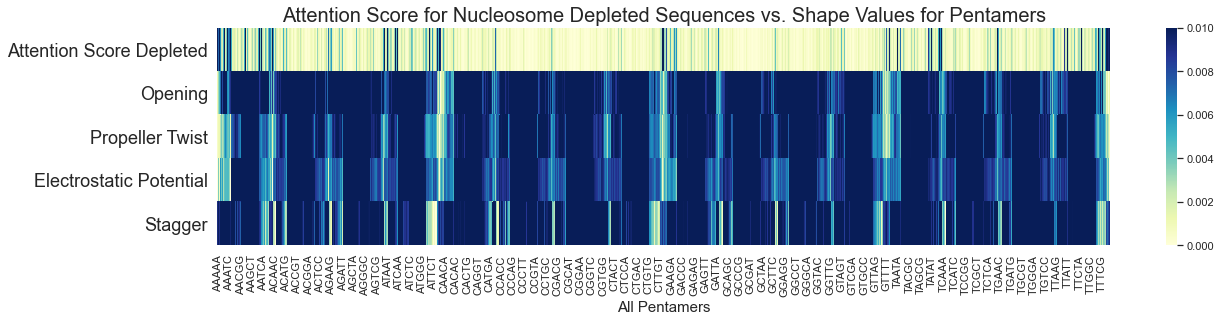

In [264]:
AllDNAshape_FL =['Shift-FL_-1', 'Shift-FL_1', 'Slide-FL_-1', 'Slide-FL_1', 'Rise-FL_-1', 'Rise-FL_1', 
               'Tilt-FL_-1', 'Tilt-FL_1', 'Roll-FL_-1', 'Roll-FL_1', 'HelT-FL_-1', 'HelT-FL_1']
AllDNAshape_FL=['Opening','ProT', 'EP','Stagger']

AllDNAshape_names=['Opening','Propeller Twist', 'Electrostatic Potential','Stagger']
data = {'Attention Score Depleted':shape_df['attention_score_norm0']}
new_df=pd.DataFrame(data)

for j in range(len(AllDNAshape_FL)):
    shape=AllDNAshape_FL[j]
    shape_arr = min_max_norm(shape_df[shape])
    new_shape_arr=[]
    for i in shape_arr:
        new_shape_arr.append(i*0.02)   

    name=AllDNAshape_names[j]
    new_df[name]=new_shape_arr

df_all_transposed = new_df.transpose()
# print(new_df)
# sns.set(rc = {'figure.figsize':(15,8)})

ax=sns.heatmap(df_all_transposed, cmap="YlGnBu", vmin=0, vmax=0.01)
ax.set_title('Attention Score for Nucleosome Depleted Sequences vs. Shape Values for Pentamers',fontsize=20)
ax.set_xlabel('All Pentamers',fontsize=15)
# ax.set_ylabel(ax.get_ylabel(),fontsize=15)
ax.set_yticklabels(ax.get_ymajorticklabels(), fontsize = 18)
fig_path='/Users/yibeijia/Downloads/nucleosome_occupancy/figs/'
plt.savefig( fig_path + 'attention_shape_heatmap_depleted.png', dpi=200, bbox_inches='tight')
# plt.show()
# df_all_transposed



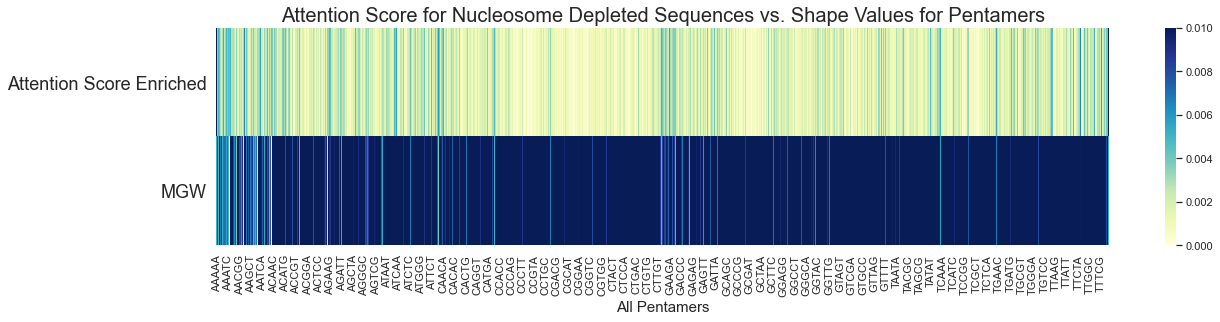

In [269]:
AllDNAshape_FL =['Shift_1','HelT_1',  'Tilt_1','Slide_1', 
'Rise_1','Roll_1']
AllDNAshape_FL=['MGW']
data = {'Attention Score Enriched':shape_df['attention_score_norm1']}
AllDNAshape_names=AllDNAshape_FL
new_df=pd.DataFrame(data)

for j in range(len(AllDNAshape_FL)):
    shape=AllDNAshape_FL[j]
    shape_arr = min_max_norm(shape_df[shape])
    new_shape_arr=[]
    for i in shape_arr:
        new_shape_arr.append(i*0.02)   

    name=AllDNAshape_names[j]
    new_df[name]=new_shape_arr

df_all_transposed = new_df.transpose()
# print(new_df)
# sns.set(rc = {'figure.figsize':(15,8)})

ax=sns.heatmap(df_all_transposed, cmap="YlGnBu", vmin=0, vmax=0.01)
ax.set_title('Attention Score for Nucleosome Depleted Sequences vs. Shape Values for Pentamers',fontsize=20)
ax.set_xlabel('All Pentamers',fontsize=15)
# ax.set_ylabel(ax.get_ylabel(),fontsize=15)
ax.set_yticklabels(ax.get_ymajorticklabels(), fontsize = 18)
fig_path='/Users/yibeijia/Downloads/nucleosome_occupancy/figs/'
plt.savefig( fig_path + 'attention_shape_heatmap_depleted.png', dpi=200, bbox_inches='tight')
# plt.show()
# df_all_transposed



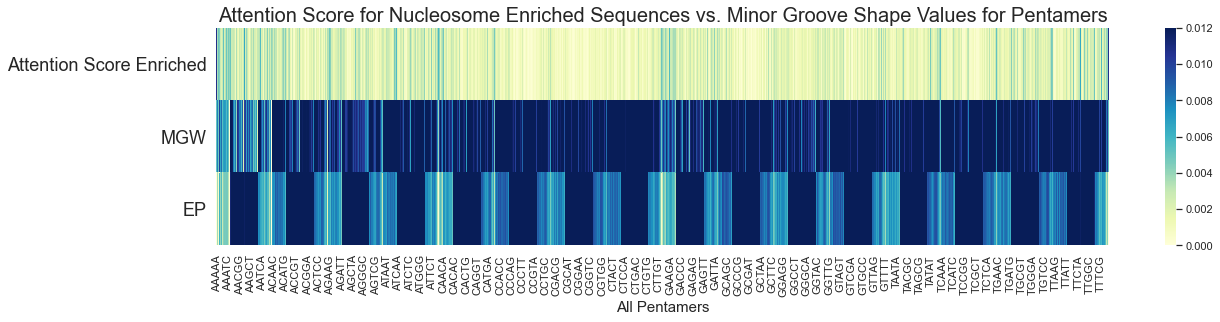

In [212]:
AllDNAshape_FL =['Shift-FL_-1', 'Shift-FL_1', 'Slide-FL_-1', 'Slide-FL_1', 'Rise-FL_-1', 'Rise-FL_1', 
               'Tilt-FL_-1', 'Tilt-FL_1', 'Roll-FL_-1', 'Roll-FL_1', 'HelT-FL_-1', 'HelT-FL_1']
AllDNAshape_FL=['MGW','EP']
data = {   'Attention Score Enriched':shape_df['attention_score_norm1']}
new_df=pd.DataFrame(data)# ax = sns.heatmap(toplot

for shape in AllDNAshape_FL:
    shape_arr = min_max_norm(shape_df[shape])
    new_shape_arr=[]
    for i in shape_arr:
        new_shape_arr.append(i*0.02)    
    new_df[shape]=new_shape_arr

    # new_df['attention_score']
    
df_all_transposed = new_df.transpose()
sns.set(rc = {'figure.figsize':(20,4)})
# print(new_df)
ax=sns.heatmap(df_all_transposed, cmap="YlGnBu", vmin=0, vmax=0.012)
ax.set_title('Attention Score for Nucleosome Enriched Sequences vs. Minor Groove Shape Values for Pentamers',fontsize=20)
ax.set_xlabel('All Pentamers',fontsize=15)
# ax.set_ylabel(ax.get_ylabel(),fontsize=15)
ax.set_yticklabels(ax.get_ymajorticklabels(), fontsize = 18)

fig_path='/Users/yibeijia/Downloads/nucleosome_occupancy/figs/'
plt.savefig( fig_path + 'attention_shape_heatmap_enriched.png', dpi=200, bbox_inches='tight')